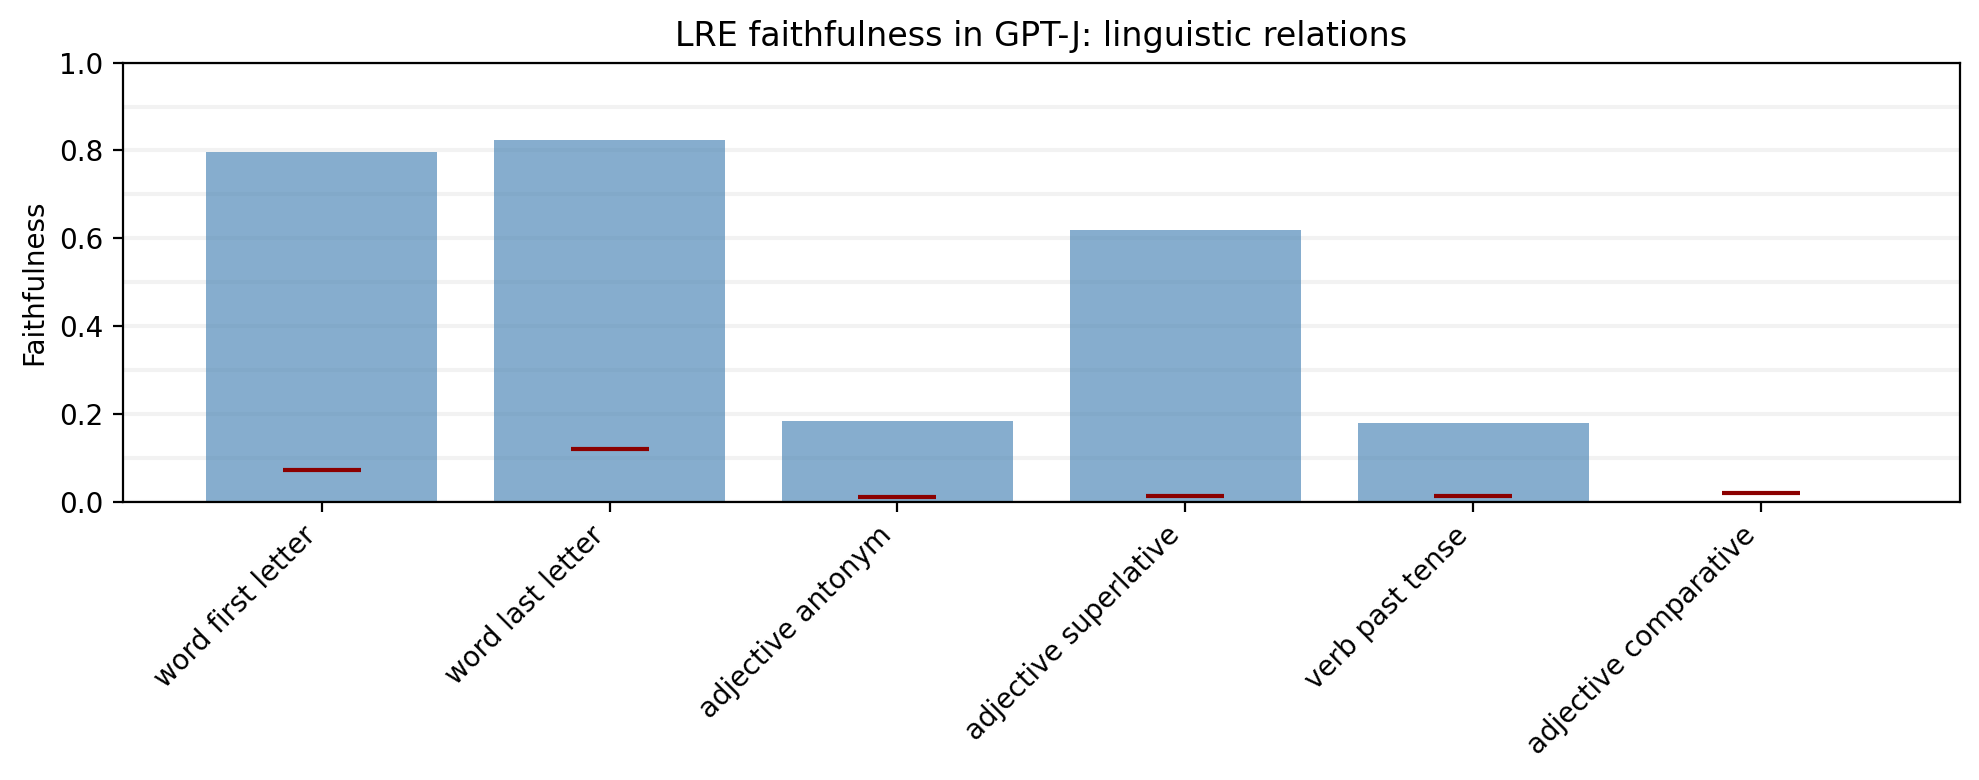

In [1]:
import sys, json
from pathlib import Path
from collections import Counter

sys.path.append("../..")

import numpy as np
import matplotlib.pyplot as plt
from src import data
from scripts.baselines.faithfulness_baselines import load_raw_results

model_name = "gptj"
path = "../../results/faithfulness_baselines_updated"
if not (Path(path) / f"{model_name}.json").exists():
    path = "../../results/faithfulness_baselines"

linguistic_relations = [
    "word first letter",
    "word last letter",
    "adjective antonym",
    "adjective superlative",
    "verb past tense",
    "adjective comparative",
]

results_raw = load_raw_results(model_name, results_path=path)
dataset = data.load_dataset()

faithfulness = {}
for rr in results_raw:
    rel = rr["relation_name"]
    if rel not in linguistic_relations:
        continue

    scores = []
    for trial in rr["trials"]:
        recall = trial.get("icl", {}).get("lre", {}).get("recall")
        if recall:
            scores.append(recall[0])
    if scores:
        faithfulness[rel] = float(np.mean(scores))

random_baselines = {}
for rel in linguistic_relations:
    relation = dataset.filter(relation_names=[rel])[0]
    objs = [s.object for s in relation.samples]
    counts = Counter(objs)
    n = len(objs)
    random_baselines[rel] = sum(c * c for c in counts.values()) / (n * n)

relations = [r for r in linguistic_relations if r in faithfulness]
scores = [faithfulness[r] for r in relations]
baselines = [random_baselines[r] for r in relations]

fig_dir = Path("figs/gptj")
fig_dir.mkdir(parents=True, exist_ok=True)

plt.rcdefaults()
plt.rcParams["figure.dpi"] = 200
# plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(relations))

ax.bar(x, scores, color="steelblue", alpha=0.65)
ax.scatter(x, baselines, color="darkred", marker="_", s=800)

ax.set_ylim(0, 1)
ax.set_ylabel("Faithfulness")
ax.set_xticks(x)
ax.set_xticklabels(relations, rotation=45, ha="right")
ax.set_title("LRE faithfulness in GPT-J: linguistic relations")

for y in np.linspace(0, 1, 11):
    ax.axhline(y, color="black", alpha=0.05, zorder=0)

fig.tight_layout()
fig.savefig(fig_dir / "gptj-fig3-linguistic-hparams.pdf", bbox_inches="tight")
plt.show()

In [7]:
faithfulness

{'word first letter': 0.7974137931034483,
 'word last letter': 0.8235294117647058,
 'adjective antonym': 0.18461538461538463,
 'adjective superlative': 0.6197183098591549,
 'verb past tense': 0.1791044776119403,
 'adjective comparative': 0.0}

In [3]:
random_baselines

{'word first letter': 0.07143472047657581,
 'word last letter': 0.1201942115321706,
 'adjective antonym': 0.011,
 'adjective superlative': 0.0128125,
 'verb past tense': 0.013157894736842105,
 'adjective comparative': 0.019896193771626297}